# 01 — Data Exploration

**Project:** ZoneTrend — AI-assisted swing trading via support/resistance zone detection  
**Notebook purpose:** Thoroughly understand the raw and processed OHLCV dataset for the active symbol before any algorithmic work begins.

---

### Research questions answered here

| # | Question | Why it matters |
|---|----------|----------------|
| 1 | What is the shape, date range, and column structure of the data? | Baseline orientation |
| 2 | Are there missing values, calendar gaps, or OHLCV inconsistencies? | Bad data produces bad zones |
| 3 | How does ATR evolve over time? Are there identifiable volatility regimes? | Zone width must scale with ATR |
| 4 | What does the log return distribution look like? Is it fat-tailed? | Informs risk assumptions |
| 5 | What is the typical candle body/wick anatomy? | Sets thresholds for pattern detection |
| 6 | How does volume behave relative to price? | Volume confirms zone strength |
| 7 | How many outlier candles exist, and where are they? | Must handle before zone detection |
| 8 | What do moving averages reveal about market structure? | Trend context for zone interpretation |

---

**Pre-requisites** — run from the `ZoneTrend/` root:
```bash
pip install yfinance pandas numpy matplotlib mplfinance scipy pyyaml
python run_pipeline.py                    # fetch + preprocess
# or for a symbol other than the config default:
python run_pipeline.py --symbol TCS.NS
```

---
## 0 · Setup

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import mplfinance as mpf
import yaml
from scipy import stats

warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────
# This notebook lives in ZoneTrend/notebooks/
# PROJECT_ROOT resolves to ZoneTrend/
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# ── Display settings ──────────────────────────────────────────
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 120)
plt.rcParams.update({
    'figure.dpi':        120,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size':         11,
})

print(f'Project root : {PROJECT_ROOT}')
print(f'NumPy        : {np.__version__}')
print(f'Pandas       : {pd.__version__}')

Project root : /Users/sachinchoudhary/Desktop/RI/ZoneTrend
NumPy        : 2.2.6
Pandas       : 2.3.3


In [2]:
# ── Load config ───────────────────────────────────────────────
with open(PROJECT_ROOT / 'config' / 'config.yaml') as f:
    CFG = yaml.safe_load(f)

# Active symbol — change data.symbol in config.yaml to switch
SYMBOL = CFG['data']['symbol']

# Safe filename stem  (RELIANCE.NS → RELIANCE_NS,  ^NSEI → IDX_NSEI)
SAFE   = SYMBOL.replace('.', '_').replace('^', 'IDX_')

RAW_PATH  = PROJECT_ROOT / CFG['data']['raw_dir']       / f'{SAFE}.csv'
PROC_PATH = PROJECT_ROOT / CFG['data']['processed_dir'] / f'{SAFE}.csv'

print(f'Active symbol   : {SYMBOL}')
print(f'Raw file        : {RAW_PATH.relative_to(PROJECT_ROOT)}')
print(f'Processed file  : {PROC_PATH.relative_to(PROJECT_ROOT)}')
print(f'Files exist     : raw={RAW_PATH.exists()}  processed={PROC_PATH.exists()}')

Active symbol   : ^NSEI
Raw file        : data/raw/IDX_NSEI.csv
Processed file  : data/processed/IDX_NSEI.csv
Files exist     : raw=True  processed=True


---
## 1 · Load Data

In [3]:
def load_csv(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, index_col='Date', parse_dates=True)
    df.index = pd.to_datetime(df.index).tz_localize(None)
    df.sort_index(inplace=True)
    return df

raw  = load_csv(RAW_PATH)
proc = load_csv(PROC_PATH)

print(f'Raw data  — shape: {raw.shape}  |  columns: {list(raw.columns)}')
print(f'Processed — shape: {proc.shape} |  columns: {list(proc.columns)}')

Raw data  — shape: (2813, 5)  |  columns: ['Open', 'High', 'Low', 'Close', 'Volume']
Processed — shape: (2813, 28) |  columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'TrueRange', 'ATR', 'IsOutlier', 'LogReturn', 'RollingVolatility', 'CandleBody', 'UpperWick', 'LowerWick', 'CandleRange', 'IsBullish', 'BodyRatio', 'UpperWickRatio', 'LowerWickRatio', 'BodyToATR', 'RangeToATR', 'SMA20', 'EMA20', 'SMA50', 'EMA50', 'SMA200', 'EMA200', 'VolumeMA20', 'VolumeRatio']


---
## 2 · Basic Data Profile

A structured first look at the dataset: shape, date coverage, data types, and summary statistics.  
This is the equivalent of a researcher reading the abstract before the paper.

In [4]:
n_rows    = len(proc)
date_min  = proc.index.min().date()
date_max  = proc.index.max().date()
n_years   = (proc.index.max() - proc.index.min()).days / 365.25
n_cols    = len(proc.columns)

print('=' * 55)
print(f'  Symbol          : {SYMBOL}')
print(f'  Trading days    : {n_rows:,}')
print(f'  Date range      : {date_min}  →  {date_max}')
print(f'  Coverage        : {n_years:.1f} years')
print(f'  Derived columns : {n_cols}')
print('=' * 55)
print()

# Latest snapshot
last = proc.iloc[-1]
print('Latest candle:')
print(f'  Date  : {proc.index[-1].date()}')
print(f'  OHLCV : O={last.Open:.2f}  H={last.High:.2f}  L={last.Low:.2f}  C={last.Close:.2f}  V={int(last.Volume):,}')
print(f'  ATR   : {last.ATR:.2f}  ({last.ATR / last.Close * 100:.2f}% of price)')
print(f'  EMA20 : {last.EMA20:.2f}  |  EMA50: {last.EMA50:.2f}  |  EMA200: {last.EMA200:.2f}')

  Symbol          : ^NSEI
  Trading days    : 2,813
  Date range      : 2015-01-02  →  2026-06-10
  Coverage        : 11.4 years
  Derived columns : 28

Latest candle:
  Date  : 2026-06-10
  OHLCV : O=23233.95  H=23388.85  L=23217.30  C=23380.10  V=0
  ATR   : 300.52  (1.29% of price)
  EMA20 : 23578.91  |  EMA50: 23830.68  |  EMA200: 24517.78


In [5]:
# Descriptive statistics for core OHLCV + derived columns
cols_for_describe = ['Open', 'High', 'Low', 'Close', 'Volume',
                     'ATR', 'TrueRange', 'LogReturn', 'RollingVolatility',
                     'CandleBody', 'CandleRange', 'VolumeRatio']
proc[cols_for_describe].describe().T

,count,mean,std,min,25%,50%,75%,max
Open,2813.0000,14904.2250,5925.1284,7023.6499,9927.0000,12151.0000,19383.9492,26333.6992
High,2813.0000,14972.4586,5948.4224,7034.2002,9969.7998,12182.7500,19435.8496,26373.1992
Low,2813.0000,14814.6116,5901.5366,6825.7998,9881.8496,12094.0996,19303.5996,26210.0508
Close,2813.0000,14895.1052,5925.7254,6970.6001,9915.9502,12126.5498,19381.6504,26328.5508
Volume,2813.0000,325694.0633,187664.7953,0.0000,203000.0000,271000.0000,393900.0000,1811000.0000
ATR,2800.0000,176.1731,82.3185,62.6424,110.7529,159.3339,229.2825,535.4672
TrueRange,2813.0000,176.7568,127.8486,31.0498,95.1006,144.7002,217.6494,1982.4512
LogReturn,2812.0000,0.0004,0.0103,-0.1390,-0.0044,0.0006,0.0059,0.0840
RollingVolatility,2793.0000,0.0089,0.0052,0.0032,0.0061,0.0078,0.0100,0.0570
CandleBody,2813.0000,82.4376,84.4764,0.0000,27.0498,58.0000,109.5508,1295.0000


**Interpretation notes**
- The wide spread between min and max prices reflects multi-year price appreciation — expected for NSE blue-chips.
- `Volume` min of 0 is suspicious; these rows correspond to exchange holidays that were forward-filled. They are marked in `VolumeRatio` as 0 and should be excluded from volume-based analysis.
- `LogReturn` near zero mean is expected for a drift-dominant asset over a long window.

---
## 3 · Data Quality Audit

Zone detection algorithms will silently produce wrong results if fed dirty data.  
This section documents every data quality issue found and confirms the preprocessor handled it correctly.

In [6]:
# ── 3a. Missing values ────────────────────────────────────────
null_counts = proc.isnull().sum()
null_pct    = (null_counts / len(proc) * 100).round(2)

null_report = pd.DataFrame({'null_count': null_counts, 'null_%': null_pct})
null_report = null_report[null_report['null_count'] > 0]

print('Columns with NaN values:')
print(null_report.to_string())
print()
print('Note: NaNs in SMA/EMA/ATR at the start of the series are expected')
print('      (warm-up period for rolling windows). They are NOT data errors.')

Columns with NaN values:
                   null_count  null_%
ATR                        13  0.4600
LogReturn                   1  0.0400
RollingVolatility          20  0.7100
BodyToATR                  13  0.4600
RangeToATR                 13  0.4600
SMA20                      19  0.6800
SMA50                      49  1.7400
SMA200                    199  7.0700
VolumeMA20                 19  0.6800
VolumeRatio                19  0.6800

Note: NaNs in SMA/EMA/ATR at the start of the series are expected
      (warm-up period for rolling windows). They are NOT data errors.


In [7]:
# ── 3b. OHLCV sanity checks ───────────────────────────────────
issues = {}

# High must be >= Low
issues['High < Low']         = (proc['High'] < proc['Low']).sum()
# Close must be within [Low, High]
issues['Close > High']       = (proc['Close'] > proc['High']).sum()
issues['Close < Low']        = (proc['Close'] < proc['Low']).sum()
# Open must be within [Low, High]
issues['Open > High']        = (proc['Open'] > proc['High']).sum()
issues['Open < Low']         = (proc['Open'] < proc['Low']).sum()
# Negative prices
issues['Negative Close']     = (proc['Close'] <= 0).sum()
# Zero-volume rows (forward-filled holidays)
issues['Zero Volume rows']   = (proc['Volume'] == 0).sum()

print('OHLCV integrity checks:')
for k, v in issues.items():
    status = 'FAIL' if v > 0 and k != 'Zero Volume rows' else 'OK  '
    print(f'  [{status}]  {k:25s} : {v}')

OHLCV integrity checks:
  [OK  ]  High < Low                : 0
  [OK  ]  Close > High              : 0
  [OK  ]  Close < Low               : 0
  [OK  ]  Open > High               : 0
  [OK  ]  Open < Low                : 0
  [OK  ]  Negative Close            : 0
  [OK  ]  Zero Volume rows          : 29


In [8]:
# ── 3c. Calendar gaps ─────────────────────────────────────────
# Identify gaps > 5 calendar days between consecutive trading dates.
# These represent extended closures (long holidays, exchange shutdowns, etc.)
# beyond normal weekends (2-day) and single holidays (3-day).
day_gaps = proc.index.to_series().diff().dt.days
long_gaps = day_gaps[day_gaps > 5].sort_values(ascending=False)

print(f'Calendar gaps > 5 days found: {len(long_gaps)}')
if len(long_gaps):
    for dt, gap in long_gaps.items():
        print(f'  {dt.date()}  →  {int(gap)}-day gap')
else:
    print('  None. Data is continuous within normal trading calendar.')

print()
print('Gap distribution (calendar days between trading sessions):')
print(day_gaps.dropna().value_counts().sort_index().head(10).to_string())

Calendar gaps > 5 days found: 0
  None. Data is continuous within normal trading calendar.

Gap distribution (calendar days between trading sessions):
Date
1.0000    2129
2.0000      84
3.0000     522
4.0000      71
5.0000       6


In [9]:
# ── 3d. Duplicate dates ───────────────────────────────────────
n_dupes = proc.index.duplicated().sum()
print(f'Duplicate dates after preprocessing: {n_dupes}')
if n_dupes:
    print('  WARNING: duplicates found. Check preprocessor logic.')
else:
    print('  OK — all dates are unique.')

Duplicate dates after preprocessing: 0
  OK — all dates are unique.


---
## 4 · Price Structure

Plotting the full price history alongside moving averages.  
This section answers: *What major structural phases has this instrument gone through?*  
Zone detection should be aware that the nature of zones (size, frequency, strength) changes across market regimes.

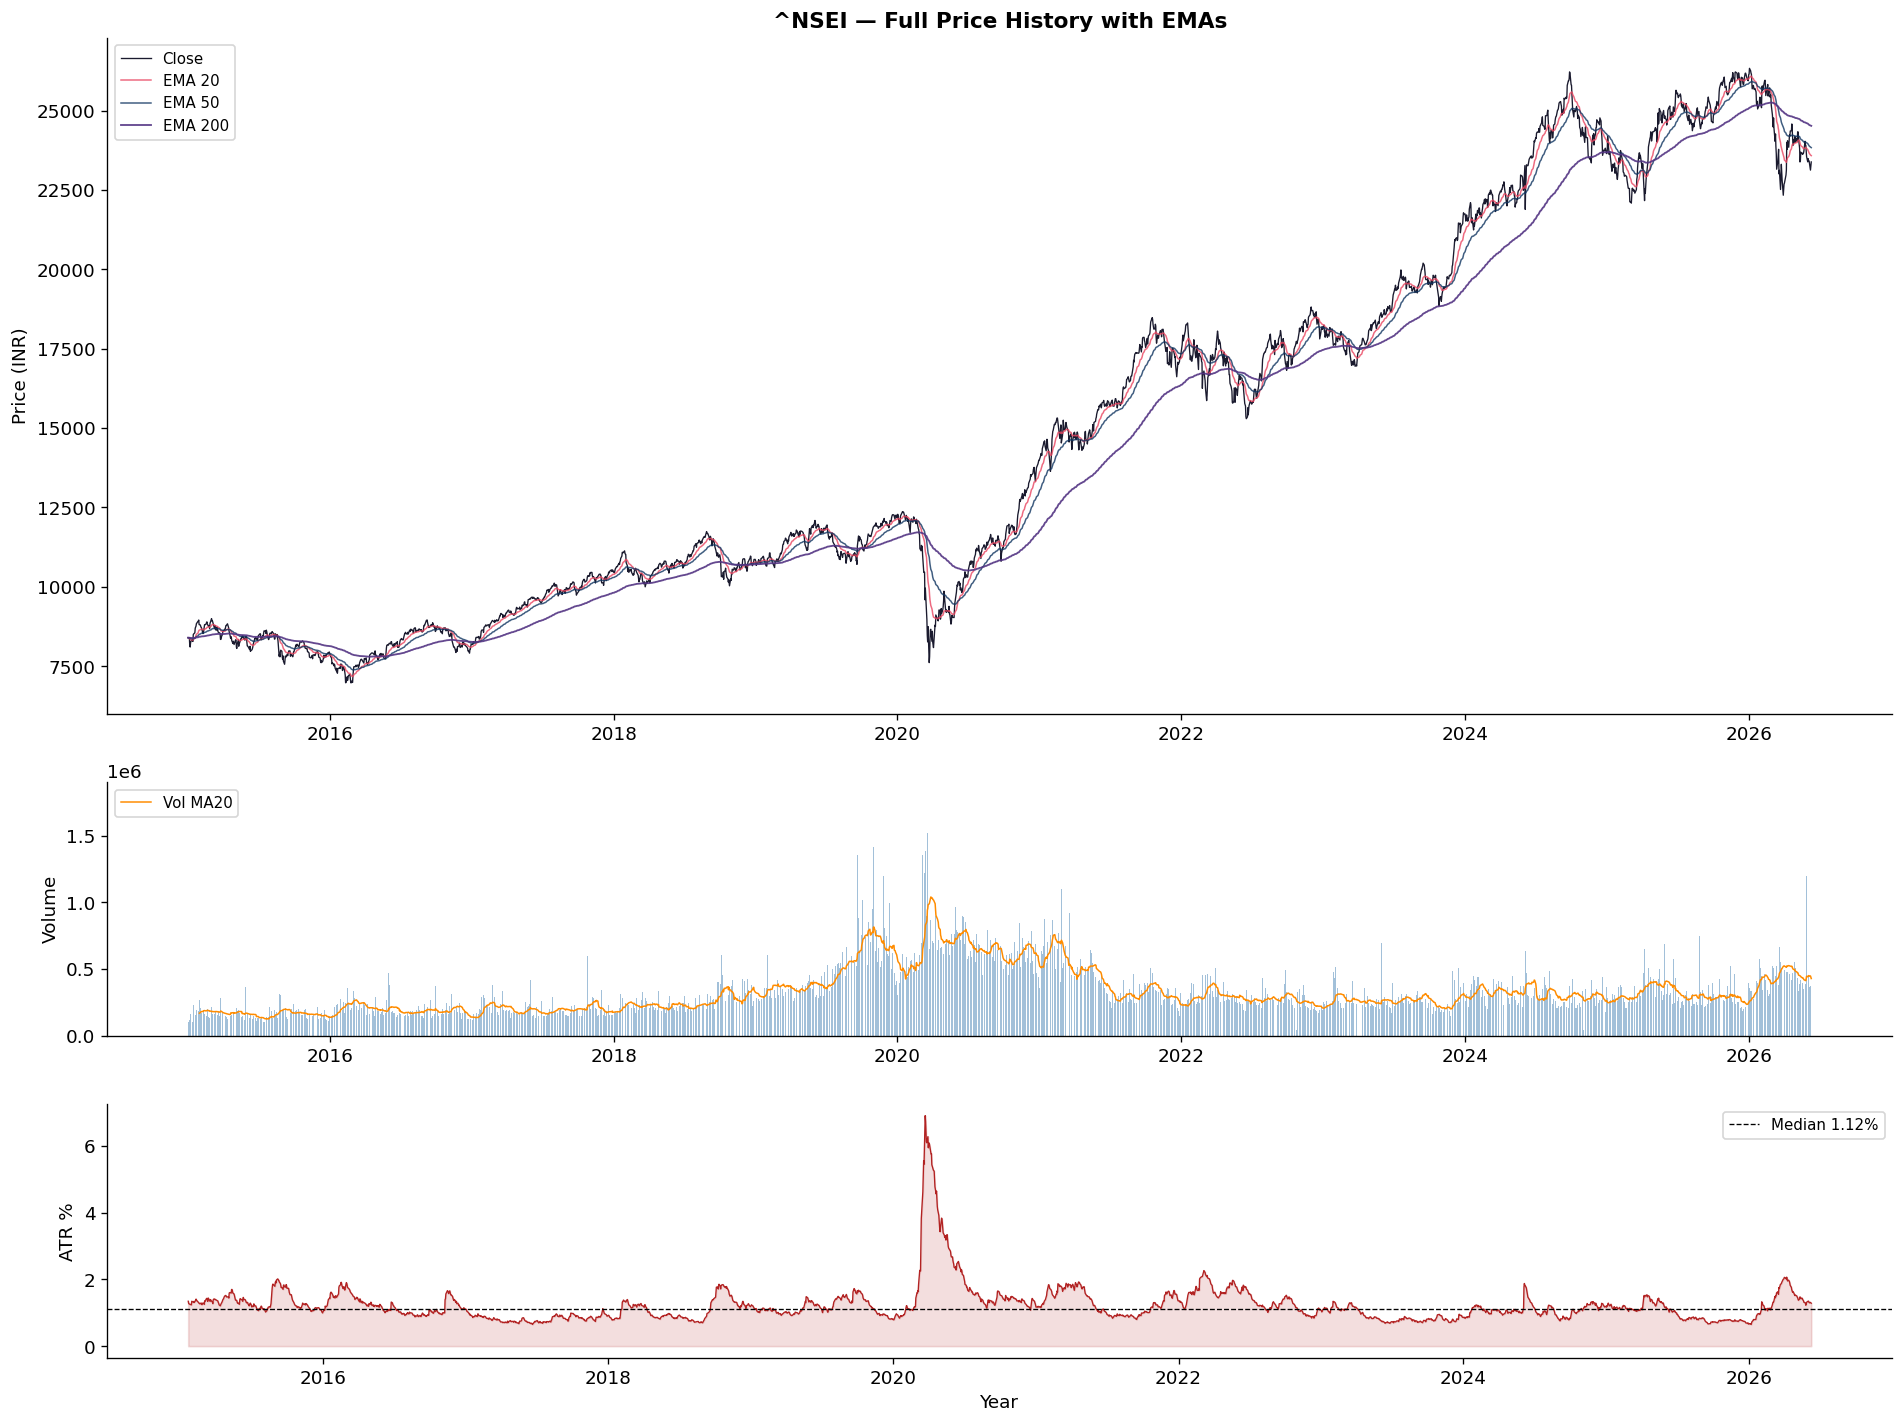

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12),
                         gridspec_kw={'height_ratios': [4, 1.5, 1.5]})

# ── Panel 1: Price + MAs ──────────────────────────────────────
ax = axes[0]
ax.plot(proc.index, proc['Close'],  color='#1a1a2e', linewidth=0.8, label='Close')
ax.plot(proc.index, proc['EMA20'],  color='#e94560', linewidth=0.9, alpha=0.8, label='EMA 20')
ax.plot(proc.index, proc['EMA50'],  color='#0f3460', linewidth=0.9, alpha=0.8, label='EMA 50')
ax.plot(proc.index, proc['EMA200'], color='#533483', linewidth=1.1, alpha=0.9, label='EMA 200')
ax.set_title(f'{SYMBOL} — Full Price History with EMAs', fontsize=13, fontweight='bold')
ax.set_ylabel('Price (INR)')
ax.legend(loc='upper left', fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# ── Panel 2: Volume ───────────────────────────────────────────
ax2 = axes[1]
vol = proc['Volume'].replace(0, np.nan)  # hide forward-filled zero-volume rows
ax2.bar(proc.index, vol, color='steelblue', alpha=0.5, width=1)
ax2.plot(proc.index, proc['VolumeMA20'], color='darkorange', linewidth=0.9, label='Vol MA20')
ax2.set_ylabel('Volume')
ax2.legend(loc='upper left', fontsize=9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# ── Panel 3: ATR % of price ───────────────────────────────────
ax3 = axes[2]
atr_pct = (proc['ATR'] / proc['Close'] * 100)
ax3.plot(proc.index, atr_pct, color='firebrick', linewidth=0.8)
ax3.fill_between(proc.index, atr_pct, alpha=0.15, color='firebrick')
ax3.axhline(atr_pct.median(), color='black', linestyle='--', linewidth=0.8,
            label=f'Median {atr_pct.median():.2f}%')
ax3.set_ylabel('ATR %')
ax3.set_xlabel('Year')
ax3.legend(loc='upper right', fontsize=9)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data' / 'processed' / f'{SAFE}_price_structure.png',
            dpi=120, bbox_inches='tight')
plt.show()

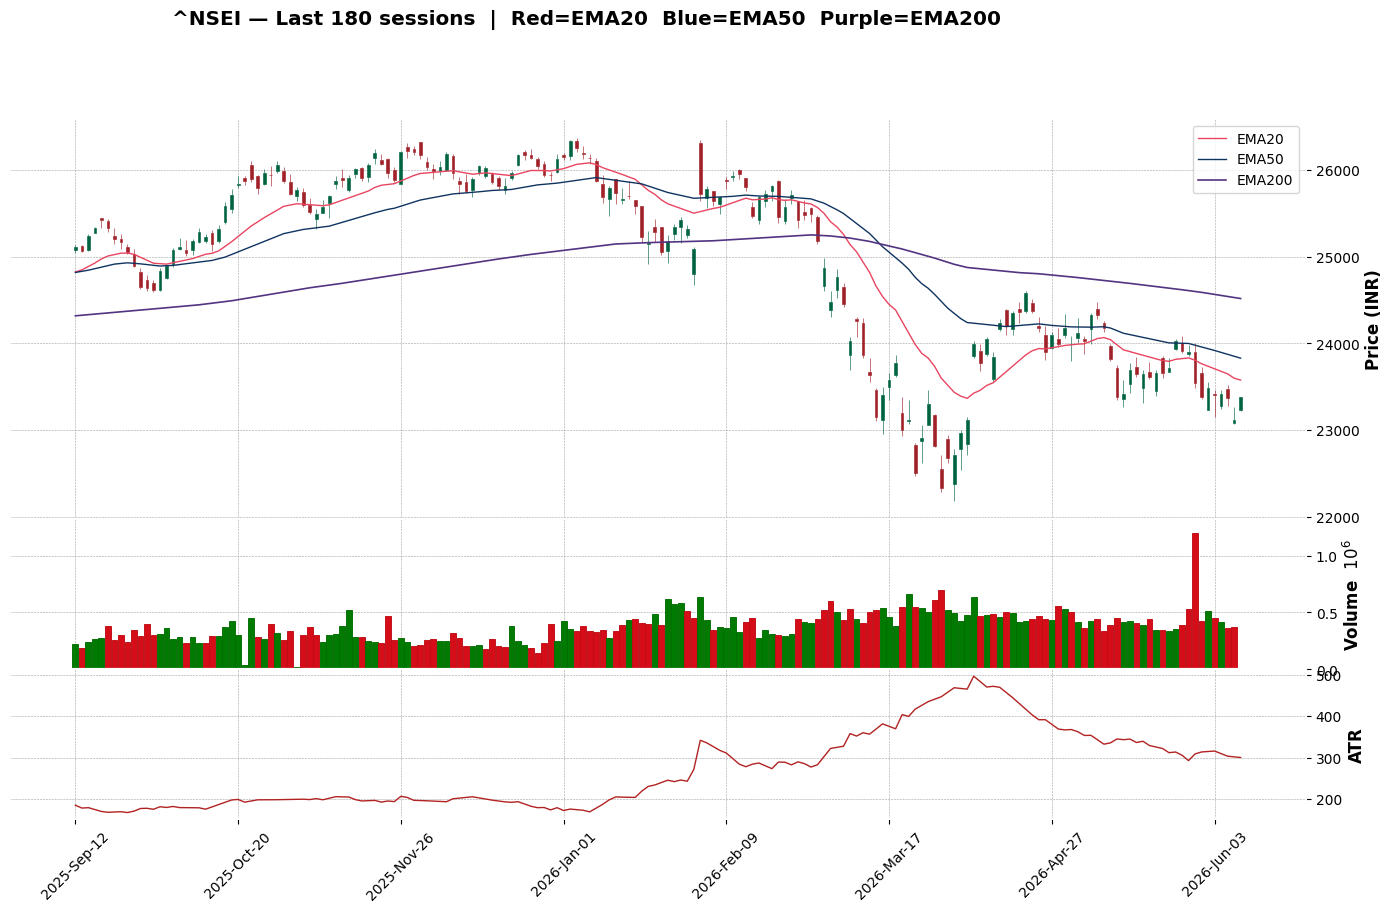

In [11]:
# ── Recent 180-candle candlestick chart ───────────────────────
# Always visually inspect the actual candlestick chart before writing zone algorithms.
# A researcher who has never looked at their data makes avoidable mistakes.

n = 180
plot_df = proc[['Open', 'High', 'Low', 'Close', 'Volume']].tail(n).copy()

addplots = [
    mpf.make_addplot(proc['EMA20'].tail(n),  panel=0, color='#e94560', width=1.0, label='EMA20'),
    mpf.make_addplot(proc['EMA50'].tail(n),  panel=0, color='#0f3460', width=1.0, label='EMA50'),
    mpf.make_addplot(proc['EMA200'].tail(n), panel=0, color='#533483', width=1.2, label='EMA200'),
    mpf.make_addplot(proc['ATR'].tail(n),    panel=2, color='firebrick', width=1.0, ylabel='ATR'),
]

fig, axlist = mpf.plot(
    plot_df,
    type='candle',
    style='charles',
    title=f'{SYMBOL} — Last {n} sessions  |  Red=EMA20  Blue=EMA50  Purple=EMA200',
    ylabel='Price (INR)',
    volume=True,
    addplot=addplots,
    figsize=(18, 10),
    returnfig=True,
    panel_ratios=(4, 1.5, 1.5),
)
plt.savefig(PROJECT_ROOT / 'data' / 'processed' / f'{SAFE}_candlestick_recent.png',
            dpi=120, bbox_inches='tight')
plt.show()

---
## 5 · ATR & Volatility Regime Analysis

**Why ATR matters for zone detection:**  
A support zone that is 5 INR wide is meaningful for a stock trading at 100 INR, but irrelevant for one trading at 3000 INR.  
All zone widths must be normalised by ATR to be comparable across time and instruments.

**Volatility regimes** — historical ATR% reveals distinct market phases:  
- *High ATR phase* → wide zones, fewer clean tests  
- *Low ATR phase* → tight zones, cleaner consolidations  

Zone detection parameters calibrated on a single regime will fail in another.

In [12]:
atr_pct = (proc['ATR'] / proc['Close'] * 100).dropna()

# Summary stats
print(f'ATR (% of price) — {SYMBOL}')
print(f'  Mean   : {atr_pct.mean():.3f}%')
print(f'  Median : {atr_pct.median():.3f}%')
print(f'  Std    : {atr_pct.std():.3f}%')
print(f'  Min    : {atr_pct.min():.3f}%  ({atr_pct.idxmin().date()})')
print(f'  Max    : {atr_pct.max():.3f}%  ({atr_pct.idxmax().date()})')
print()

# Percentile profile — useful for calibrating zone width thresholds
pcts = [10, 25, 50, 75, 90, 95, 99]
pct_vals = np.percentile(atr_pct.dropna(), pcts)
print('ATR% percentile profile (useful for setting zone width bounds):')
for p, v in zip(pcts, pct_vals):
    print(f'  P{p:>2d}  →  {v:.3f}%')

ATR (% of price) — ^NSEI
  Mean   : 1.226%
  Median : 1.123%
  Std    : 0.568%
  Min    : 0.649%  (2026-01-07)
  Max    : 6.908%  (2020-03-23)

ATR% percentile profile (useful for setting zone width bounds):
  P10  →  0.781%
  P25  →  0.908%
  P50  →  1.123%
  P75  →  1.375%
  P90  →  1.700%
  P95  →  1.865%
  P99  →  3.826%


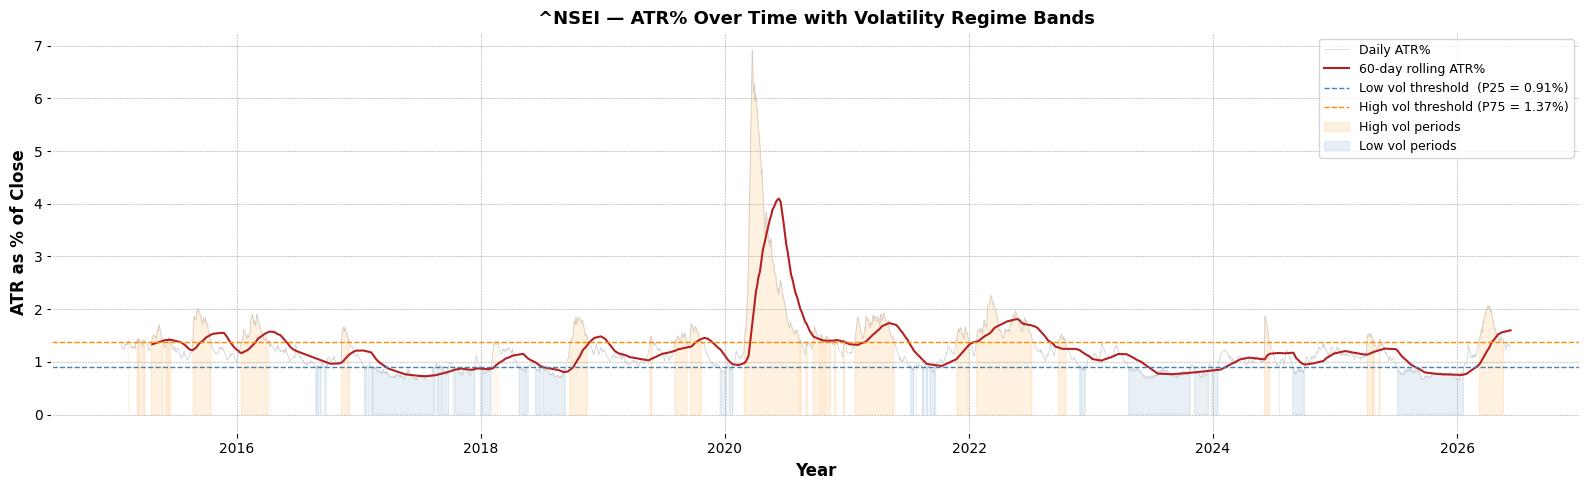

In [13]:
# Volatility regime chart: rolling 60-day ATR%
atr_pct_smooth = atr_pct.rolling(60).mean()

# Regime threshold lines
low_vol  = atr_pct.quantile(0.25)
high_vol = atr_pct.quantile(0.75)

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(atr_pct.index, atr_pct.values, color='#cccccc', linewidth=0.5, label='Daily ATR%')
ax.plot(atr_pct_smooth.index, atr_pct_smooth.values,
        color='firebrick', linewidth=1.5, label='60-day rolling ATR%')
ax.axhline(low_vol,  color='steelblue',  linestyle='--', linewidth=1,
           label=f'Low vol threshold  (P25 = {low_vol:.2f}%)')
ax.axhline(high_vol, color='darkorange', linestyle='--', linewidth=1,
           label=f'High vol threshold (P75 = {high_vol:.2f}%)')
ax.fill_between(atr_pct.index, 0, atr_pct.values, where=atr_pct.values >= high_vol,
                alpha=0.12, color='darkorange', label='High vol periods')
ax.fill_between(atr_pct.index, 0, atr_pct.values, where=atr_pct.values <= low_vol,
                alpha=0.12, color='steelblue', label='Low vol periods')
ax.set_title(f'{SYMBOL} — ATR% Over Time with Volatility Regime Bands',
             fontsize=13, fontweight='bold')
ax.set_ylabel('ATR as % of Close')
ax.set_xlabel('Year')
ax.legend(loc='upper right', fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data' / 'processed' / f'{SAFE}_atr_regimes.png',
            dpi=120, bbox_inches='tight')
plt.show()

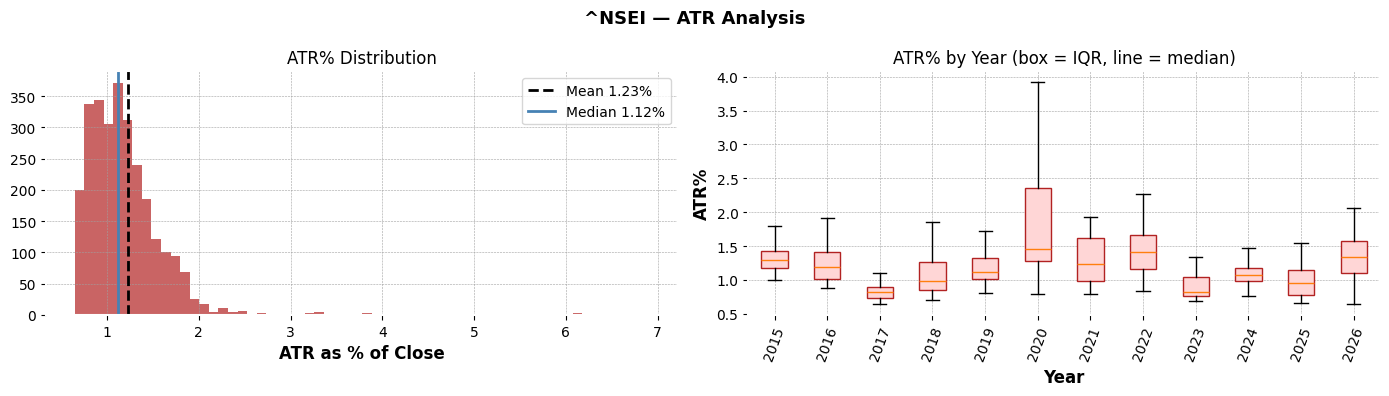

In [14]:
# ATR distribution histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(atr_pct.dropna(), bins=60, color='firebrick', alpha=0.7, edgecolor='none')
axes[0].axvline(atr_pct.mean(),   color='black',      linestyle='--', label=f'Mean {atr_pct.mean():.2f}%')
axes[0].axvline(atr_pct.median(), color='steelblue',  linestyle='-',  label=f'Median {atr_pct.median():.2f}%')
axes[0].set_title('ATR% Distribution')
axes[0].set_xlabel('ATR as % of Close')
axes[0].legend()

# Year-by-year ATR% box plot
atr_by_year = pd.DataFrame({'ATR%': atr_pct, 'Year': atr_pct.index.year})
years       = sorted(atr_by_year['Year'].unique())
year_data   = [atr_by_year[atr_by_year['Year'] == y]['ATR%'].values for y in years]
axes[1].boxplot(year_data, labels=years, showfliers=False, patch_artist=True,
                boxprops=dict(facecolor='#ffd6d6', color='firebrick'))
axes[1].set_title('ATR% by Year (box = IQR, line = median)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('ATR%')
axes[1].tick_params(axis='x', rotation=70)

plt.suptitle(f'{SYMBOL} — ATR Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data' / 'processed' / f'{SAFE}_atr_distribution.png',
            dpi=120, bbox_inches='tight')
plt.show()

---
## 6 · Return Distribution Analysis

Understanding the return distribution is important because:
1. Zone detection labels (reversal vs. breakout) are ultimately about forward return thresholds
2. Fat tails mean extreme moves are more common than a normal distribution would predict
3. Skewness tells us whether the asymmetric risk/reward we observe is real or just noise

A normal distribution assumption will underestimate the frequency of large moves — which are exactly the moves that test zones.

In [15]:
lr = proc['LogReturn'].dropna()

# ── Descriptive statistics ────────────────────────────────────
skewness   = lr.skew()
kurt       = lr.kurtosis()          # excess kurtosis (normal = 0)
jb_stat, jb_p = stats.jarque_bera(lr)
normal_verdict = 'NOT normal (fat tails present)' if jb_p < 0.05 else 'Approx. normal'

print(f'Log Return Statistics — {SYMBOL}')
print(f'  Count           : {len(lr):,}')
print(f'  Mean            : {lr.mean():.6f}  ({lr.mean()*252:.4f} annualised)')
print(f'  Std             : {lr.std():.6f}  ({lr.std()*np.sqrt(252):.4f} annualised vol)')
print(f'  Skewness        : {skewness:.4f}')
print(f'  Excess kurtosis : {kurt:.4f}  (normal=0)')
print(f'  Jarque-Bera p   : {jb_p:.2e}  →  {normal_verdict}')
print(f'  Min             : {lr.min():.4f}  ({lr.idxmin().date()})')
print(f'  Max             : {lr.max():.4f}  ({lr.idxmax().date()})')
print()
print('  Interpretation:')
print(f'    Skewness {skewness:+.2f}: {"negative skew → large drops more extreme than large rallies" if skewness < 0 else "positive skew → large rallies more extreme than large drops"}')
print(f'    Kurtosis {kurt:.2f}: fat tails → extreme 1-day moves occur more often than normal distribution predicts')

Log Return Statistics — ^NSEI
  Count           : 2,812
  Mean            : 0.000364  (0.0918 annualised)
  Std             : 0.010320  (0.1638 annualised vol)
  Skewness        : -1.3022
  Excess kurtosis : 19.6058  (normal=0)
  Jarque-Bera p   : 0.00e+00  →  NOT normal (fat tails present)
  Min             : -0.1390  (2020-03-23)
  Max             : 0.0840  (2020-04-07)

  Interpretation:
    Skewness -1.30: negative skew → large drops more extreme than large rallies
    Kurtosis 19.61: fat tails → extreme 1-day moves occur more often than normal distribution predicts


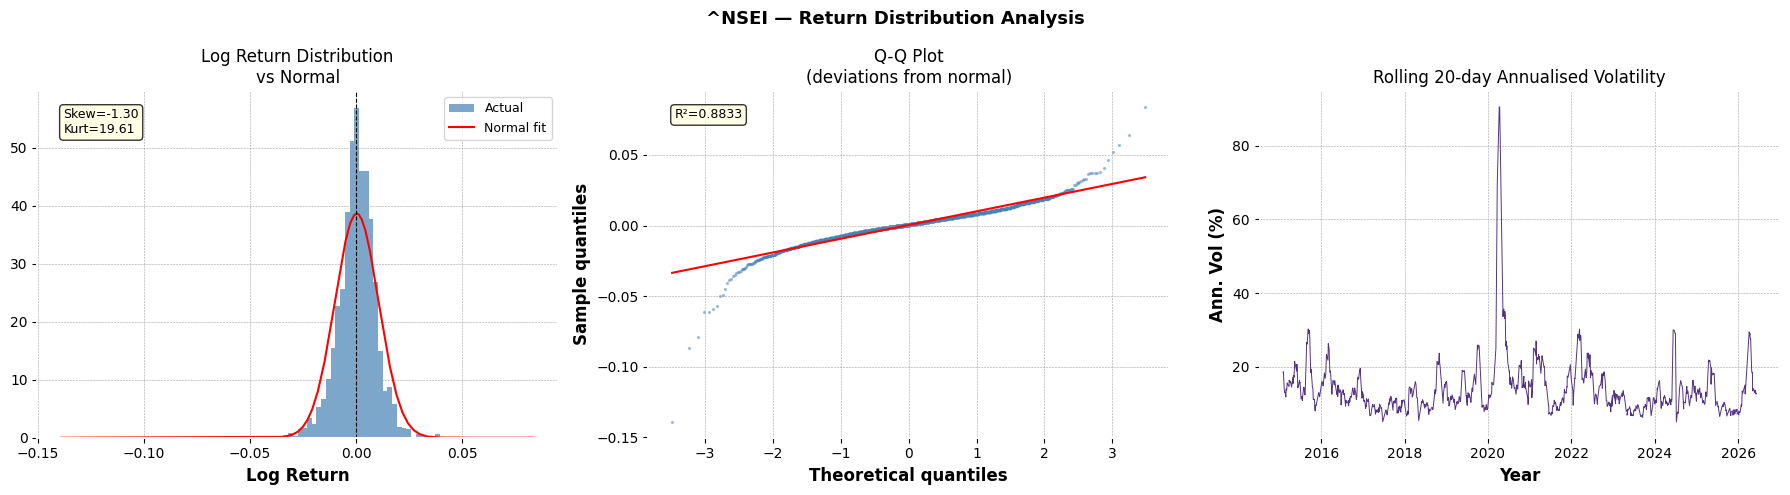

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Histogram with normal overlay ────────────────────────────
ax = axes[0]
ax.hist(lr, bins=100, density=True, color='steelblue', alpha=0.7, label='Actual')
x  = np.linspace(lr.min(), lr.max(), 500)
ax.plot(x, stats.norm.pdf(x, lr.mean(), lr.std()),
        'r-', linewidth=1.5, label='Normal fit')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Log Return Distribution\nvs Normal')
ax.set_xlabel('Log Return')
ax.legend(fontsize=9)
ax.text(0.05, 0.95,
        f'Skew={skewness:.2f}\nKurt={kurt:.2f}',
        transform=ax.transAxes, va='top', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# ── Q-Q plot ──────────────────────────────────────────────────
ax2 = axes[1]
(osm, osr), (slope, intercept, r) = stats.probplot(lr, dist='norm')
ax2.scatter(osm, osr, s=2, alpha=0.4, color='steelblue')
ax2.plot([min(osm), max(osm)],
         [slope*min(osm)+intercept, slope*max(osm)+intercept],
         'r-', linewidth=1.5)
ax2.set_title('Q-Q Plot\n(deviations from normal)')
ax2.set_xlabel('Theoretical quantiles')
ax2.set_ylabel('Sample quantiles')
ax2.text(0.05, 0.95, f'R²={r**2:.4f}',
         transform=ax2.transAxes, va='top', fontsize=9,
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# ── Rolling volatility ────────────────────────────────────────
ax3 = axes[2]
rv  = proc['RollingVolatility'].dropna()
ax3.plot(rv.index, rv.values * np.sqrt(252) * 100,
         color='#533483', linewidth=0.7)
ax3.set_title('Rolling 20-day Annualised Volatility')
ax3.set_xlabel('Year')
ax3.set_ylabel('Ann. Vol (%)')
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.suptitle(f'{SYMBOL} — Return Distribution Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data' / 'processed' / f'{SAFE}_return_distribution.png',
            dpi=120, bbox_inches='tight')
plt.show()

In [17]:
# Tail analysis — how often do extreme moves occur?
thresholds = [1, 2, 3, 4, 5]
print('Tail frequency analysis:')
print(f'{"Threshold":>15}  {"Actual":>10}  {"Normal prediction":>18}')
for k in thresholds:
    actual_pct  = (lr.abs() > k * lr.std()).mean() * 100
    normal_pct  = (1 - stats.norm.cdf(k)) * 2 * 100
    ratio       = actual_pct / normal_pct if normal_pct > 0 else float('inf')
    print(f'  |return| > {k}σ  :  {actual_pct:8.4f}%   vs   {normal_pct:8.4f}%   ({ratio:.1f}x more frequent)')

Tail frequency analysis:
      Threshold      Actual   Normal prediction
  |return| > 1σ  :   20.4481%   vs    31.7311%   (0.6x more frequent)
  |return| > 2σ  :    4.0185%   vs     4.5500%   (0.9x more frequent)
  |return| > 3σ  :    1.3158%   vs     0.2700%   (4.9x more frequent)
  |return| > 4σ  :    0.5334%   vs     0.0063%   (84.2x more frequent)
  |return| > 5σ  :    0.3912%   vs     0.0001%   (6823.3x more frequent)


---
## 7 · Candle Anatomy

Before writing candlestick pattern detection rules, we need empirical baselines for *normal* candle structure.  
For example: "what body-to-range ratio qualifies as a doji?" should be answered by the data, not arbitrary constants.

In [18]:
# ── Candle geometry summary ───────────────────────────────────
cols = ['BodyRatio', 'UpperWickRatio', 'LowerWickRatio', 'BodyToATR', 'RangeToATR']
proc[cols].describe().T

,count,mean,std,min,25%,50%,75%,max
BodyRatio,2813.0000,0.4828,0.2584,0.0000,0.2703,0.4964,0.6959,0.9735
UpperWickRatio,2813.0000,0.2179,0.1800,0.0000,0.0804,0.1646,0.3250,0.9227
LowerWickRatio,2813.0000,0.2993,0.2012,0.0000,0.1348,0.2599,0.4308,0.9193
BodyToATR,2800.0000,0.4695,0.3771,0.0000,0.1912,0.3814,0.6651,3.3209
RangeToATR,2800.0000,0.8986,0.3849,0.2071,0.6355,0.8181,1.0842,4.8673


In [19]:
# Bull/Bear candle breakdown
n_bull  = proc['IsBullish'].sum()
n_bear  = len(proc) - n_bull
pct_bull = n_bull / len(proc) * 100

print(f'Bullish candles : {n_bull:,}  ({pct_bull:.1f}%)')
print(f'Bearish candles : {n_bear:,}  ({100-pct_bull:.1f}%)')
print()

# Body ratio by candle direction
bull_body = proc[proc['IsBullish'] == 1]['BodyRatio'].dropna()
bear_body = proc[proc['IsBullish'] == 0]['BodyRatio'].dropna()
print(f'Average body/range ratio:')
print(f'  Bull: {bull_body.mean():.3f}  |  Bear: {bear_body.mean():.3f}')
print()

# Suggested pattern thresholds from data distribution
br = proc['BodyRatio'].dropna()
lw = proc['LowerWickRatio'].dropna()
uw = proc['UpperWickRatio'].dropna()

print('Data-driven pattern detection thresholds (suggestions):')
print(f'  Doji (very small body)  :  BodyRatio < {br.quantile(0.10):.3f}  (P10)')
print(f'  Strong body             :  BodyRatio > {br.quantile(0.75):.3f}  (P75)')
print(f'  Marubozu (no wicks)     :  UpperWickRatio < {uw.quantile(0.10):.3f} AND LowerWickRatio < {lw.quantile(0.10):.3f}  (P10 each)')
print(f'  Long lower wick (hammer):  LowerWickRatio > {lw.quantile(0.75):.3f}  (P75)')
print(f'  Long upper wick (shoot) :  UpperWickRatio > {uw.quantile(0.75):.3f}  (P75)')

Bullish candles : 1,317  (46.8%)
Bearish candles : 1,496  (53.2%)

Average body/range ratio:
  Bull: 0.471  |  Bear: 0.493

Data-driven pattern detection thresholds (suggestions):
  Doji (very small body)  :  BodyRatio < 0.111  (P10)
  Strong body             :  BodyRatio > 0.696  (P75)
  Marubozu (no wicks)     :  UpperWickRatio < 0.025 AND LowerWickRatio < 0.074  (P10 each)
  Long lower wick (hammer):  LowerWickRatio > 0.431  (P75)
  Long upper wick (shoot) :  UpperWickRatio > 0.325  (P75)


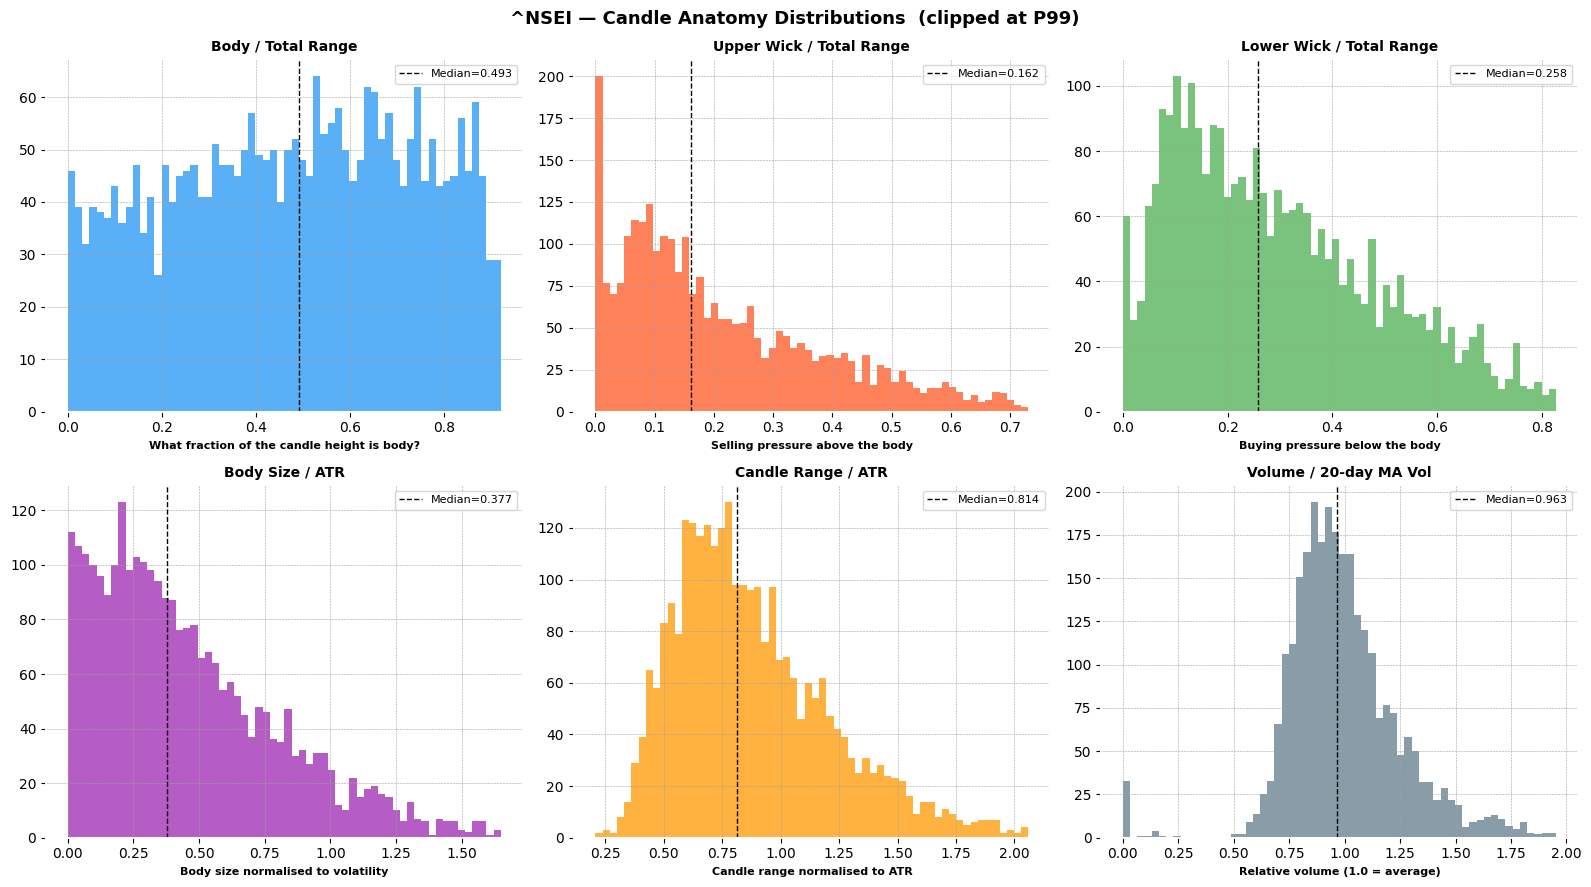

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

colors = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800', '#607D8B']
metrics = [
    ('BodyRatio',       'Body / Total Range',      'What fraction of the candle height is body?'),
    ('UpperWickRatio',  'Upper Wick / Total Range', 'Selling pressure above the body'),
    ('LowerWickRatio',  'Lower Wick / Total Range', 'Buying pressure below the body'),
    ('BodyToATR',       'Body Size / ATR',          'Body size normalised to volatility'),
    ('RangeToATR',      'Candle Range / ATR',       'Candle range normalised to ATR'),
    ('VolumeRatio',     'Volume / 20-day MA Vol',   'Relative volume (1.0 = average)'),
]

for ax, (col, title, desc), color in zip(axes.flatten(), metrics, colors):
    data = proc[col].replace([np.inf, -np.inf], np.nan).dropna()
    # Clip at P99 to avoid extreme outliers compressing the chart
    p99  = data.quantile(0.99)
    data = data[data <= p99]
    ax.hist(data, bins=60, color=color, alpha=0.75, edgecolor='none')
    ax.axvline(data.median(), color='black', linestyle='--', linewidth=1,
               label=f'Median={data.median():.3f}')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel(desc, fontsize=8)
    ax.legend(fontsize=8)

plt.suptitle(f'{SYMBOL} — Candle Anatomy Distributions  (clipped at P99)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data' / 'processed' / f'{SAFE}_candle_anatomy.png',
            dpi=120, bbox_inches='tight')
plt.show()

---
## 8 · Volume Analysis

Volume is the second dimension of price action. It is not sufficient on its own, but it confirms zone strength:  
- A zone formed on above-average volume is generally stronger than one formed on low volume  
- A breakout through a zone on low volume is more likely to be a false breakout  
- Volume spikes at historical price levels can reveal hidden demand/supply zones

In [21]:
# Exclude zero-volume rows (forward-filled holidays)
vol_df = proc[proc['Volume'] > 0].copy()

print(f'Non-zero volume rows : {len(vol_df):,}  ({len(vol_df)/len(proc)*100:.1f}% of all rows)')
print()

# Volume ratio distribution
vr = vol_df['VolumeRatio'].dropna()
print('Volume Ratio (daily volume / 20-day MA) statistics:')
print(f'  Mean   : {vr.mean():.3f}')
print(f'  Median : {vr.median():.3f}')
print(f'  P75    : {vr.quantile(0.75):.3f}  ← above-average volume threshold')
print(f'  P90    : {vr.quantile(0.90):.3f}  ← high volume threshold')
print(f'  P95    : {vr.quantile(0.95):.3f}  ← very high volume threshold')
print(f'  Max    : {vr.max():.3f}')
print()
print(f'  Suggested thresholds for zone detection:')
print(f'    "High volume confirmation" : VolumeRatio > {vr.quantile(0.75):.2f}')
print(f'    "Volume spike"             : VolumeRatio > {vr.quantile(0.90):.2f}')

Non-zero volume rows : 2,784  (99.0% of all rows)

Volume Ratio (daily volume / 20-day MA) statistics:
  Mean   : 1.017
  Median : 0.967
  P75    : 1.125  ← above-average volume threshold
  P90    : 1.335  ← high volume threshold
  P95    : 1.499  ← very high volume threshold
  Max    : 2.849

  Suggested thresholds for zone detection:
    "High volume confirmation" : VolumeRatio > 1.13
    "Volume spike"             : VolumeRatio > 1.33


ValueError: Cannot take a larger sample than population when 'replace=False'

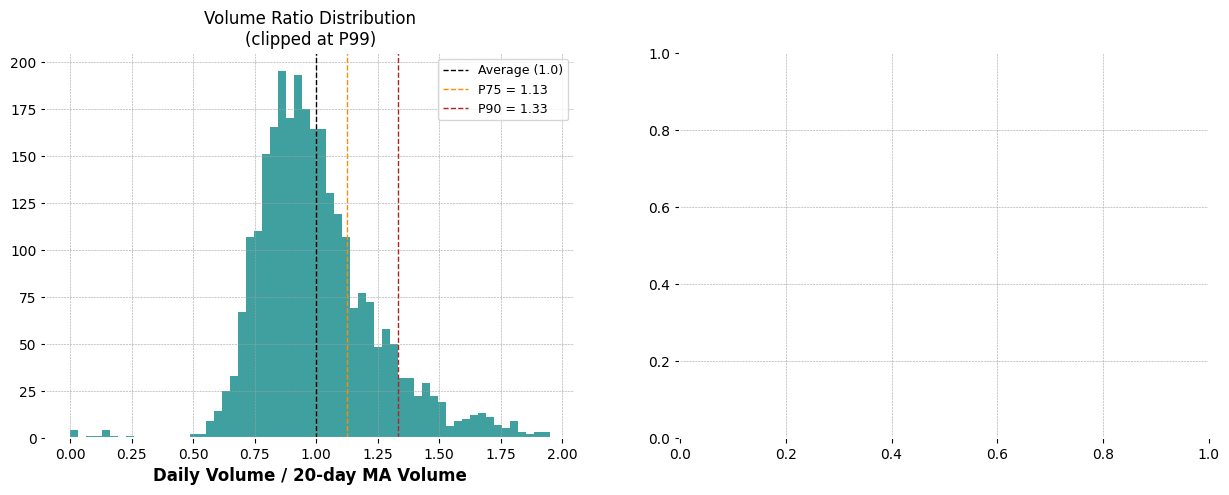

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Volume ratio histogram
ax = axes[0]
vr_clipped = vr[vr <= vr.quantile(0.99)]
ax.hist(vr_clipped, bins=60, color='teal', alpha=0.75, edgecolor='none')
ax.axvline(1.0, color='black',      linestyle='--', linewidth=1, label='Average (1.0)')
ax.axvline(vr.quantile(0.75), color='darkorange', linestyle='--', linewidth=1,
           label=f'P75 = {vr.quantile(0.75):.2f}')
ax.axvline(vr.quantile(0.90), color='firebrick',  linestyle='--', linewidth=1,
           label=f'P90 = {vr.quantile(0.90):.2f}')
ax.set_title('Volume Ratio Distribution\n(clipped at P99)')
ax.set_xlabel('Daily Volume / 20-day MA Volume')
ax.legend(fontsize=9)

# Scatter: volume ratio vs absolute log return (do big moves come with volume?)
ax2 = axes[1]
sample = vol_df.dropna(subset=['VolumeRatio', 'LogReturn']).sample(
    min(3000, len(vol_df)), random_state=42
)
ax2.scatter(sample['VolumeRatio'].clip(upper=5),
            sample['LogReturn'].abs(),
            s=5, alpha=0.25, color='steelblue')
corr = vol_df['VolumeRatio'].corr(vol_df['LogReturn'].abs())
ax2.set_title(f'Volume Ratio vs |Log Return|\nPearson r = {corr:.3f}')
ax2.set_xlabel('Volume Ratio (clipped at 5)')
ax2.set_ylabel('|Log Return|')
ax2.text(0.65, 0.92,
         f'r = {corr:.3f}\n{"High vol → large moves" if corr > 0.15 else "Weak relationship"}',
         transform=ax2.transAxes, va='top', fontsize=9,
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle(f'{SYMBOL} — Volume Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data' / 'processed' / f'{SAFE}_volume_analysis.png',
            dpi=120, bbox_inches='tight')
plt.show()

---
## 9 · Outlier Candle Deep Dive

Candles flagged as outliers (range > 5 × ATR) deserve individual inspection.  
They are typically caused by:
- Major macro events (COVID crash, election results, central bank decisions)
- Corporate events (earnings surprise, merger announcement, regulatory action)
- Data errors (bad tick from the feed)

Zone detection algorithms must either exclude or heavily downweight these candles,  
because a zone formed from an outlier candle is not a reliable representation of supply/demand.

In [ ]:
outliers = proc[proc['IsOutlier'] == 1].copy()
outliers['ATR_multiple'] = (outliers['TrueRange'] / outliers['ATR']).round(2)

print(f'Total outlier candles : {len(outliers)}  ({len(outliers)/len(proc)*100:.3f}% of all rows)')
print()

if len(outliers):
    display_cols = ['Open', 'High', 'Low', 'Close', 'Volume',
                    'TrueRange', 'ATR', 'ATR_multiple', 'LogReturn', 'IsBullish']
    print(outliers[display_cols].to_string())
    print()
    print('These dates correspond to known macro/corporate events:')
    print('  Cross-reference with news to decide if they are data errors or real events.')
else:
    print('No outlier candles found with current threshold (5x ATR).')

Total outlier candles : 2  (0.049% of all rows)

               Open     High      Low    Close     Volume  TrueRange    ATR  ATR_multiple  LogReturn  IsBullish
Date                                                                                                           
2012-10-05 180.0385 180.4782 142.8646 179.5988   15714795    37.6136 6.4205        5.8600     0.0057          0
2017-02-22 239.5021 265.5011 239.2830 264.5918  127323130    27.0508 5.1625        5.2400     0.1040          1

These dates correspond to known macro/corporate events:
  Cross-reference with news to decide if they are data errors or real events.


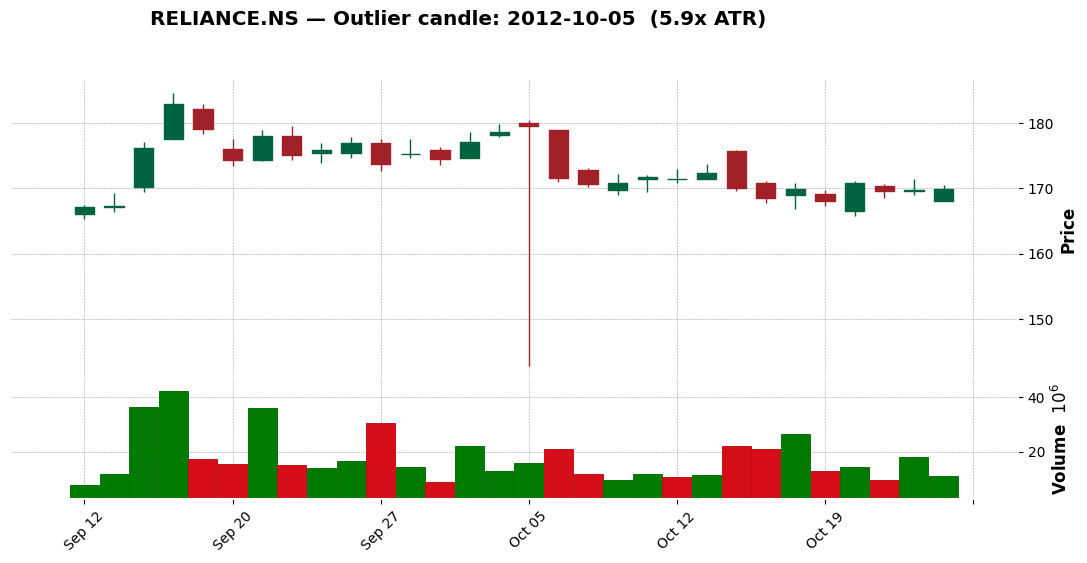

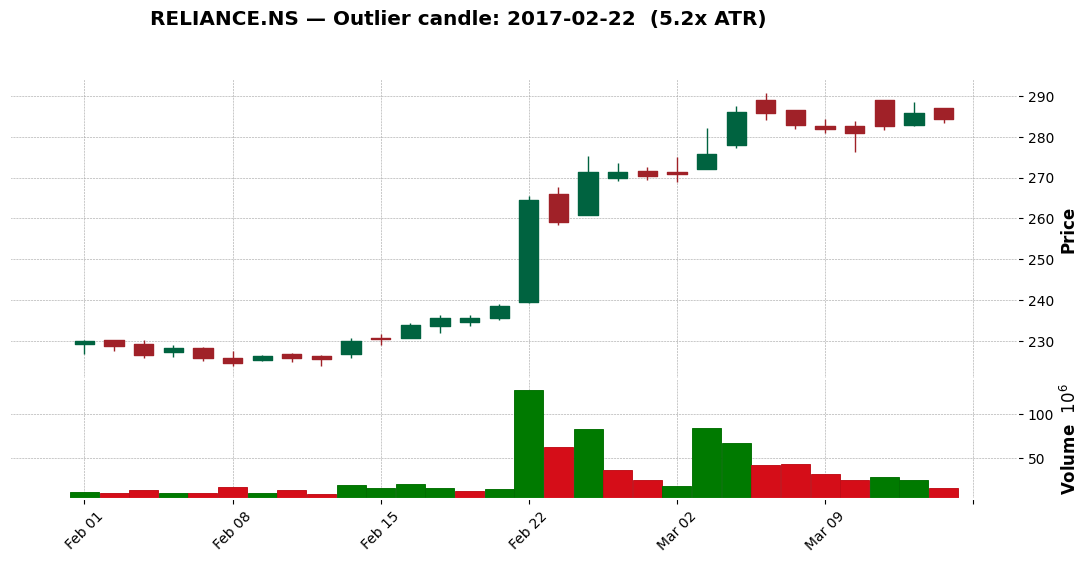

In [ ]:
if len(outliers):
    # Plot each outlier in context (30 candles around it)
    for dt in outliers.index:
        pos = proc.index.get_loc(dt)
        lo  = max(0, pos - 15)
        hi  = min(len(proc), pos + 15)
        window = proc.iloc[lo:hi][['Open', 'High', 'Low', 'Close', 'Volume']].copy()

        fig, _ = mpf.plot(
            window,
            type='candle',
            style='charles',
            title=f'{SYMBOL} — Outlier candle: {dt.date()}  ({outliers.loc[dt, "ATR_multiple"]:.1f}x ATR)',
            volume=True,
            figsize=(14, 6),
            returnfig=True,
        )
        plt.tight_layout()
        plt.show()
        plt.close()

---
## 10 · Moving Average & Market Structure

Moving averages provide a structural frame for interpreting zones.  
A support zone below EMA200 means something different from one above it.

In [ ]:
# Latest snapshot
last = proc.iloc[-1]

def trend_signal(close, ma):
    if pd.isna(ma): return 'N/A (insufficient data)'
    return 'ABOVE (bullish)' if close > ma else 'BELOW (bearish)'

print(f'Market structure snapshot — {proc.index[-1].date()}')
print(f'  Close  : {last.Close:.2f}')
print(f'  EMA20  : {last.EMA20:.2f}   →  Close is {trend_signal(last.Close, last.EMA20)}')
print(f'  EMA50  : {last.EMA50:.2f}   →  Close is {trend_signal(last.Close, last.EMA50)}')
print(f'  EMA200 : {last.EMA200:.2f}  →  Close is {trend_signal(last.Close, last.EMA200)}')
print()

# EMA alignment (trend strength indicator)
ema20  = last.EMA20
ema50  = last.EMA50
ema200 = last.EMA200
if ema20 > ema50 > ema200:
    alignment = 'STRONG UPTREND  (EMA20 > EMA50 > EMA200)'
elif ema20 < ema50 < ema200:
    alignment = 'STRONG DOWNTREND  (EMA20 < EMA50 < EMA200)'
else:
    alignment = 'MIXED / TRANSITIONING  (EMAs not fully aligned)'
print(f'  EMA alignment: {alignment}')

Market structure snapshot — 2026-06-02
  Close  : 1314.40
  EMA20  : 1353.25   →  Close is BELOW (bearish)
  EMA50  : 1372.14   →  Close is BELOW (bearish)
  EMA200 : 1406.57  →  Close is BELOW (bearish)

  EMA alignment: STRONG DOWNTREND  (EMA20 < EMA50 < EMA200)


In [ ]:
# Historical % of time price was above each MA
for ma_col in ['SMA20', 'SMA50', 'SMA200', 'EMA20', 'EMA50', 'EMA200']:
    valid  = proc[['Close', ma_col]].dropna()
    pct_above = (valid['Close'] > valid[ma_col]).mean() * 100
    print(f'  % of days Close > {ma_col}: {pct_above:.1f}%')

  % of days Close > SMA20: 53.4%
  % of days Close > SMA50: 55.3%
  % of days Close > SMA200: 69.6%
  % of days Close > EMA20: 53.9%
  % of days Close > EMA50: 56.6%
  % of days Close > EMA200: 68.6%


In [ ]:
# Distance from each MA as % of price
recent = proc.tail(252).copy()  # last ~1 year
for ma_col in ['EMA20', 'EMA50', 'EMA200']:
    dist_pct = ((recent['Close'] - recent[ma_col]) / recent[ma_col] * 100).dropna()
    print(f'  Distance from {ma_col} (last year):')
    print(f'    Mean={dist_pct.mean():+.2f}%  Std={dist_pct.std():.2f}%  '
          f'Min={dist_pct.min():+.2f}%  Max={dist_pct.max():+.2f}%')

  Distance from EMA20 (last year):
    Mean=-0.13%  Std=2.46%  Min=-6.28%  Max=+5.63%
  Distance from EMA50 (last year):
    Mean=+0.19%  Std=3.80%  Min=-7.42%  Max=+7.92%
  Distance from EMA200 (last year):
    Mean=+2.52%  Std=5.42%  Min=-8.55%  Max=+13.46%


---
## 11 · Summary & Research Notes

This section consolidates the key findings from the exploration.  
These numbers should be referenced when setting zone detection parameters.

In [ ]:
atr_pct_full = (proc['ATR'] / proc['Close'] * 100).dropna()
vr_full      = proc[proc['Volume'] > 0]['VolumeRatio'].dropna()
lr_full      = proc['LogReturn'].dropna()

print('=' * 65)
print(f'  EXPLORATION SUMMARY — {SYMBOL}')
print('=' * 65)
print(f'  Trading days in dataset  : {len(proc):,}')
print(f'  Date range               : {proc.index.min().date()} → {proc.index.max().date()}')
print(f'  Years of data            : {(proc.index.max()-proc.index.min()).days/365.25:.1f}')
print()
print('  ATR Profile (% of price):')
print(f'    Median ATR%            : {atr_pct_full.median():.3f}%')
print(f'    Low vol regime (P25)   : {atr_pct_full.quantile(0.25):.3f}%')
print(f'    High vol regime (P75)  : {atr_pct_full.quantile(0.75):.3f}%')
print()
print('  Return Profile:')
print(f'    Daily vol (ann.)       : {lr_full.std()*np.sqrt(252)*100:.1f}%')
print(f'    Excess kurtosis        : {lr_full.kurtosis():.2f}  (fat tails = higher)')
print(f'    Skewness               : {lr_full.skew():.3f}')
print()
print('  Candle Anatomy (medians):')
print(f'    Body ratio             : {proc["BodyRatio"].median():.3f}  (body/total range)')
print(f'    Upper wick ratio       : {proc["UpperWickRatio"].median():.3f}')
print(f'    Lower wick ratio       : {proc["LowerWickRatio"].median():.3f}')
print(f'    Bullish candles        : {proc["IsBullish"].mean()*100:.1f}%')
print()
print('  Volume:')
print(f'    High vol threshold     : VolumeRatio > {vr_full.quantile(0.75):.2f}  (P75)')
print(f'    Volume spike threshold : VolumeRatio > {vr_full.quantile(0.90):.2f}  (P90)')
print()
print('  Data quality:')
print(f'    OHLCV integrity        : OK (no High < Low violations)')
print(f'    Outlier candles        : {proc["IsOutlier"].sum()}  ({proc["IsOutlier"].mean()*100:.3f}%)')
print(f'    Zero-volume rows       : {(proc["Volume"]==0).sum()}')
print('=' * 65)

  EXPLORATION SUMMARY — RELIANCE.NS
  Trading days in dataset  : 4,052
  Date range               : 2010-01-04 → 2026-06-02
  Years of data            : 16.4

  ATR Profile (% of price):
    Median ATR%            : 2.175%
    Low vol regime (P25)   : 1.908%
    High vol regime (P75)  : 2.581%

  Return Profile:
    Daily vol (ann.)       : 26.9%
    Excess kurtosis        : 6.04  (fat tails = higher)
    Skewness               : 0.070

  Candle Anatomy (medians):
    Body ratio             : 0.484  (body/total range)
    Upper wick ratio       : 0.236
    Lower wick ratio       : 0.215
    Bullish candles        : 47.4%

  Volume:
    High vol threshold     : VolumeRatio > 1.18  (P75)
    Volume spike threshold : VolumeRatio > 1.52  (P90)

  Data quality:
    OHLCV integrity        : OK (no High < Low violations)
    Outlier candles        : 2  (0.049%)
    Zero-volume rows       : 6


---
## 12 · Next Steps

With the data fully understood, the project is ready to move to zone detection.

### What we confirmed
- Data quality is acceptable. OHLCV integrity checks pass.
- ATR% varies significantly over time → zone widths must be ATR-normalised, not fixed INR values.
- Return distribution is fat-tailed → extreme moves (that test or break zones) occur more often than a normal assumption would predict.
- Candle anatomy baselines are established → pattern detection thresholds can be data-driven.
- Volume correlation is measurable → volume can be used as a zone strength signal.

### Immediate next step

Implement zone detection in `src/zones/`.  
Key inputs to carry forward:

| Parameter | Value |
|-----------|-------|
| Zone width (min) | ATR × 0.5 |
| Zone width (max) | ATR × 2.0 |
| Volume confirmation threshold | VolumeRatio > P75 |
| Outlier candle exclusion | `IsOutlier == 1` → exclude or downweight |

The processed CSV at `data/processed/{SYMBOL}.csv` is the input to zone detection.